
# Data Mining_2_Module_2
## Advanced Regression

**Target:** `PCIAT-PCIAT_Total`

This notebook contains **only the regression branch** of Module 2.

The pipeline:

- use the Module 1 dataset after outlier removal;
- use only rows where `PCIAT-PCIAT_Total` is genuinely observed;
- never impute the regression target;
- remove `sii` from predictors because it would introduce direct leakage;
- do not standardize the predictors because all final regressors are tree-based;
- use the original 80/20 split with `random_state=42`;
- compare baseline and tuned Random Forest, Gradient Boosting, XGBoost and LightGBM;
- evaluate MAE, RMSE and R²;
- inspect feature importance, permutation importance, predictions and residuals;
- perform the final sensitivity analysis excluding `PreInt_EduHx-computerinternet_hoursday`.



## Before running


In [1]:

# Run this before importing NumPy, scikit-learn, XGBoost or LightGBM.

import os
import sys

if "torch" in sys.modules:
    raise RuntimeError(
        "PyTorch is already loaded. Restart the kernel and run this notebook from the first cell."
    )

for variable in [
    "OMP_NUM_THREADS",
    "OPENBLAS_NUM_THREADS",
    "MKL_NUM_THREADS",
    "VECLIB_MAXIMUM_THREADS",
    "NUMEXPR_NUM_THREADS",
]:
    os.environ[variable] = "1"

print("Native thread limits set to 1.")
print("PyTorch loaded:", "torch" in sys.modules)


Native thread limits set to 1.
PyTorch loaded: False


## 0. Setup and project paths

In [2]:

from pathlib import Path
import json
import warnings

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display, Markdown
from sklearn.model_selection import train_test_split

RANDOM_STATE = 42

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 120)

PROJECT_CANDIDATES = [
    Path.cwd(),
    Path.cwd().parent,
    Path("/Users/sarabiiavasco/Codice/DATA MINING/Progetto DM2"),
    Path("/Users/sarabiiavasco/Codice/DATA MINING/PROGETTO DM2"),
    Path("/Users/sarabiiavasco/Codice/DATA MINING/progetto dm2"),
]

def looks_like_project_dir(path):
    return (
        path.exists()
        and (
            (path / "data").exists()
            or (path / "06_module1_after_outlier_removal.csv").exists()
            or (path / "dataset_finale_da_usare_per_tutto.csv").exists()
        )
    )

PROJECT_DIR = next(
    (p for p in PROJECT_CANDIDATES if looks_like_project_dir(p)),
    None,
)

if PROJECT_DIR is None:
    raise FileNotFoundError(
        "Project folder not found. Update PROJECT_CANDIDATES."
    )

PROCESSED_DIR = PROJECT_DIR / "data" / "processed"
REGRESSION_DIR = PROJECT_DIR / "artifacts" / "module2_regression"

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
REGRESSION_DIR.mkdir(parents=True, exist_ok=True)

print("Project directory:", PROJECT_DIR)
print("Regression artifacts:", REGRESSION_DIR)


Project directory: /Users/sarabiiavasco/Codice/DATA MINING/PROGETTO DM2
Regression artifacts: /Users/sarabiiavasco/Codice/DATA MINING/PROGETTO DM2/artifacts/module2_regression



## 1. Load the Module 1 output

The preferred input is:

`data/processed/06_module1_after_outlier_removal.csv`

The old `dataset_finale_da_usare_per_tutto.csv` is accepted only as a historical fallback.


In [3]:

def find_regression_input():
    candidates = [
        PROCESSED_DIR / "06_module1_after_outlier_removal.csv",
        PROJECT_DIR / "06_module1_after_outlier_removal.csv",
        PROJECT_DIR / "dataset_finale_da_usare_per_tutto.csv",
        PROCESSED_DIR / "dataset_finale_da_usare_per_tutto.csv",
    ]

    for path in candidates:
        if path.exists():
            return path

    matches = [
        p for p in PROJECT_DIR.rglob("dataset_finale_da_usare_per_tutto.csv")
        if "artifacts" not in p.parts
    ]

    if len(matches) == 1:
        return matches[0]

    raise FileNotFoundError(
        "Could not find the Module 1 output dataset."
    )

REGRESSION_DATASET_PATH = find_regression_input()
df_reg_source = pd.read_csv(REGRESSION_DATASET_PATH)

print("Loaded:", REGRESSION_DATASET_PATH)
print("Shape:", df_reg_source.shape)

if df_reg_source.shape != (8253, 30):
    warnings.warn(
        "The dataset does not match the final project checkpoint (8253, 30). "
        f"Current shape: {df_reg_source.shape}."
    )


Loaded: /Users/sarabiiavasco/Codice/DATA MINING/PROGETTO DM2/data/processed/06_module1_after_outlier_removal.csv
Shape: (8286, 30)


/var/folders/b4/hvnr8by950nd8ffj3bwdqh3w0000gn/T/ipykernel_31920/3987791061.py:32: UserWarning: The dataset does not match the final project checkpoint (8253, 30). Current shape: (8286, 30).
  warnings.warn(



# Advanced Regression

Regression is performed only on records where `PCIAT-PCIAT_Total` is genuinely observed.

- Missing target values are **not imputed**.
- `sii` is removed because it is derived from the same construct and would leak target information.
- All regressors are tree-based, so feature standardization is intentionally omitted.


In [4]:
TARGET_REG = "PCIAT-PCIAT_Total"
PREINT_COL = "PreInt_EduHx-computerinternet_hoursday"

df_reg = (
    df_reg_source.loc[df_reg_source[TARGET_REG].notna()]
    .copy()
    .reset_index(drop=True)
)

if "Basic_Demos-Sex" in df_reg.columns:
    df_reg["Basic_Demos-Sex"] = df_reg["Basic_Demos-Sex"].astype(int)

reg_feature_cols = [
    col
    for col in df_reg.columns
    if col not in [TARGET_REG, "sii"]
]

print("Full Module 2 rows:", len(df_reg_source))
print("Observed PCIAT rows:", len(df_reg))
print("Excluded missing-target rows:", len(df_reg_source) - len(df_reg))
print("Regression predictors:", len(reg_feature_cols))

if len(df_reg_source) == 8253 and len(df_reg) != 2652:
    warnings.warn("Observed PCIAT count differs from the report checkpoint (2,652).")

Full Module 2 rows: 8286
Observed PCIAT rows: 2655
Excluded missing-target rows: 5631
Regression predictors: 28


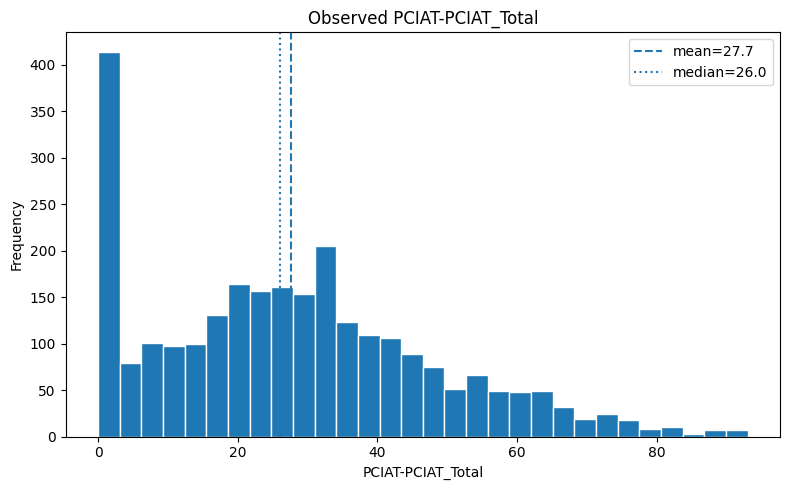

count    2655.000000
mean       27.691525
std        20.234611
min         0.000000
25%        12.000000
50%        26.000000
75%        40.000000
max        93.000000
Name: PCIAT-PCIAT_Total, dtype: float64
Skewness: 0.539


In [5]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(df_reg[TARGET_REG], bins=30, edgecolor="white")
ax.axvline(df_reg[TARGET_REG].mean(), linestyle="--", label=f"mean={df_reg[TARGET_REG].mean():.1f}")
ax.axvline(df_reg[TARGET_REG].median(), linestyle=":", label=f"median={df_reg[TARGET_REG].median():.1f}")
ax.set_xlabel(TARGET_REG)
ax.set_ylabel("Frequency")
ax.set_title("Observed PCIAT-PCIAT_Total")
ax.legend()
plt.tight_layout()
plt.show()

print(df_reg[TARGET_REG].describe())
print("Skewness:", round(df_reg[TARGET_REG].skew(), 3))

In [6]:
corr_reg = (
    df_reg[reg_feature_cols + [TARGET_REG]]
    .corr(numeric_only=True)[TARGET_REG]
    .drop(TARGET_REG)
    .sort_values(key=lambda s: s.abs(), ascending=False)
)

display(
    corr_reg
    .rename("pearson_r")
    .to_frame()
    .head(15)
    .round(3)
)

,pearson_r
Basic_Demos-Age,0.408
Physical-Height,0.406
PreInt_EduHx-computerinternet_hoursday,0.359
Physical-Weight,0.358
BIA-BIA_ICW,0.306
BIA-BIA_ECW,0.281
FGC-FGC_CU,0.254
Physical-BMI_recalc,0.230
SDS-SDS_Total_Raw,0.228
BIA-BIA_Fat,0.217


## 11. Regression split and model search spaces

The regression uses an **80/20** split because the observed-target subset is much smaller than the classification dataset.

Hyperparameter tuning uses `RandomizedSearchCV` with:

- 30 sampled configurations;
- 5-fold CV;
- negative MAE as the optimization score.

In [7]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance

try:
    from xgboost import XGBRegressor
    from lightgbm import LGBMRegressor
except ImportError as exc:
    raise ImportError(
        "Regression requires xgboost and lightgbm. "
        "Install with: pip install xgboost lightgbm"
    ) from exc

reg_indices = np.arange(len(df_reg))

reg_train_idx, reg_test_idx = train_test_split(
    reg_indices,
    test_size=0.20,
    random_state=RANDOM_STATE,
)

X_reg_train = df_reg.loc[reg_train_idx, reg_feature_cols].to_numpy()
X_reg_test = df_reg.loc[reg_test_idx, reg_feature_cols].to_numpy()
y_reg_train = df_reg.loc[reg_train_idx, TARGET_REG].to_numpy()
y_reg_test = df_reg.loc[reg_test_idx, TARGET_REG].to_numpy()

print("Regression train:", X_reg_train.shape)
print("Regression test:", X_reg_test.shape)

Regression train: (2124, 28)
Regression test: (531, 28)


In [8]:
reg_model_specs = {
    "Random Forest": {
        "class": RandomForestRegressor,
        "baseline_params": {
            "n_estimators": 100,
            "criterion": "squared_error",
            "max_depth": None,
            "min_samples_split": 2,
            "min_samples_leaf": 1,
            "max_features": 1.0,
            "random_state": RANDOM_STATE,
            "n_jobs": 1,
        },
        "fixed_params": {
            "random_state": RANDOM_STATE,
            "n_jobs": 1,
        },
        "param_dist": {
            "max_depth": [None, 5, 10, 15, 20, 25],
            "min_samples_split": [2, 5, 10, 20, 50],
            "min_samples_leaf": [1, 5, 10, 20],
            "max_features": [1.0, "sqrt", "log2", 0.5],
            "n_estimators": [100, 200, 300],
        },
    },
    "Gradient Boosting": {
        "class": GradientBoostingRegressor,
        "baseline_params": {
            "n_estimators": 100,
            "learning_rate": 0.1,
            "max_depth": 3,
            "subsample": 1.0,
            "random_state": RANDOM_STATE,
        },
        "fixed_params": {
            "random_state": RANDOM_STATE,
        },
        "param_dist": {
            "n_estimators": [100, 200, 300, 500],
            "learning_rate": [0.01, 0.05, 0.1, 0.2],
            "max_depth": [2, 3, 4, 5, 6],
            "subsample": [0.6, 0.7, 0.8, 1.0],
            "min_samples_leaf": [1, 5, 10, 20],
        },
    },
    "XGBoost": {
        "class": XGBRegressor,
        "baseline_params": {
            "objective": "reg:squarederror",
            "random_state": RANDOM_STATE,
            "n_jobs": 1,
        },
        "fixed_params": {
            "objective": "reg:squarederror",
            "random_state": RANDOM_STATE,
            "n_jobs": 1,
        },
        "param_dist": {
            "n_estimators": [100, 200, 300, 500],
            "learning_rate": [0.01, 0.05, 0.1, 0.2],
            "max_depth": [3, 4, 5, 6, 8],
            "subsample": [0.6, 0.7, 0.8, 1.0],
            "min_child_weight": [1, 3, 5, 10],
            "reg_alpha": [0.0, 0.1, 0.5, 1.0],
            "reg_lambda": [0.5, 1.0, 2.0, 5.0],
        },
    },
    "LightGBM": {
        "class": LGBMRegressor,
        "baseline_params": {
            "boosting_type": "gbdt",
            "objective": "regression",
            "random_state": RANDOM_STATE,
            "n_jobs": 1,
            "verbose": -1,
            "subsample_freq": 1,
        },
        "fixed_params": {
            "boosting_type": "gbdt",
            "objective": "regression",
            "random_state": RANDOM_STATE,
            "n_jobs": 1,
            "verbose": -1,
            "subsample_freq": 1,
        },
        "param_dist": {
            "n_estimators": [100, 200, 300, 500],
            "learning_rate": [0.01, 0.05, 0.1, 0.2],
            "num_leaves": [15, 31, 63, 127],
            "max_depth": [-1, 5, 8, 12],
            "subsample": [0.6, 0.7, 0.8, 1.0],
            "reg_alpha": [0.0, 0.1, 0.5, 1.0],
            "reg_lambda": [0.0, 0.5, 1.0, 2.0],
            "min_child_samples": [10, 20, 30, 50],
        },
    },
}

## 12. Train baseline and tuned regression models

In [9]:
regression_rows = []
regression_models = {}
regression_predictions = {}
regression_best_params = {}

def regression_metrics(model, X_eval, y_eval):
    pred = model.predict(X_eval)
    return {
        "MAE": mean_absolute_error(y_eval, pred),
        "RMSE": np.sqrt(mean_squared_error(y_eval, pred)),
        "R2": r2_score(y_eval, pred),
    }, pred

for model_name, spec in reg_model_specs.items():
    baseline = spec["class"](**spec["baseline_params"])
    baseline.fit(X_reg_train, y_reg_train)
    baseline_metrics, _ = regression_metrics(
        baseline,
        X_reg_test,
        y_reg_test,
    )

    regression_rows.append({
        "model": model_name,
        "version": "Baseline",
        **baseline_metrics,
    })

    tuned_path = REGRESSION_DIR / f"{model_name.lower().replace(' ', '_')}.joblib"

    if tuned_path.exists():
        tuned_model = joblib.load(tuned_path)
        print(f"Loaded cached tuned {model_name}.")
    else:
        search = RandomizedSearchCV(
            spec["class"](**spec["fixed_params"]),
            param_distributions=spec["param_dist"],
            n_iter=30,
            cv=5,
            scoring="neg_mean_absolute_error",
            random_state=RANDOM_STATE,
            n_jobs=1,
            refit=True,
        )
        search.fit(X_reg_train, y_reg_train)
        tuned_model = search.best_estimator_
        regression_best_params[model_name] = search.best_params_
        joblib.dump(tuned_model, tuned_path)

    tuned_metrics, tuned_pred = regression_metrics(
        tuned_model,
        X_reg_test,
        y_reg_test,
    )

    regression_rows.append({
        "model": model_name,
        "version": "Tuned",
        **tuned_metrics,
    })

    regression_models[model_name] = tuned_model
    regression_predictions[model_name] = tuned_pred

    print(
        f"{model_name:<18} "
        f"baseline MAE={baseline_metrics['MAE']:.4f} R2={baseline_metrics['R2']:.4f} | "
        f"tuned MAE={tuned_metrics['MAE']:.4f} R2={tuned_metrics['R2']:.4f}"
    )

regression_results = pd.DataFrame(regression_rows)
display(regression_results.round(4))

Random Forest      baseline MAE=13.9180 R2=0.2786 | tuned MAE=13.7865 R2=0.2903
Gradient Boosting  baseline MAE=14.0540 R2=0.2701 | tuned MAE=13.8213 R2=0.2871
XGBoost            baseline MAE=14.7612 R2=0.1702 | tuned MAE=13.7733 R2=0.2944
LightGBM           baseline MAE=14.0168 R2=0.2645 | tuned MAE=13.6736 R2=0.3004


,model,version,MAE,RMSE,R2
0,Random Forest,Baseline,13.9180,17.4202,0.2786
1,Random Forest,Tuned,13.7865,17.2780,0.2903
2,Gradient Boosting,Baseline,14.0540,17.5220,0.2701
3,Gradient Boosting,Tuned,13.8213,17.3177,0.2871
4,XGBoost,Baseline,14.7612,18.6828,0.1702
5,XGBoost,Tuned,13.7733,17.2276,0.2944
6,LightGBM,Baseline,14.0168,17.5896,0.2645
7,LightGBM,Tuned,13.6736,17.1549,0.3004


## 13. Regression feature importance

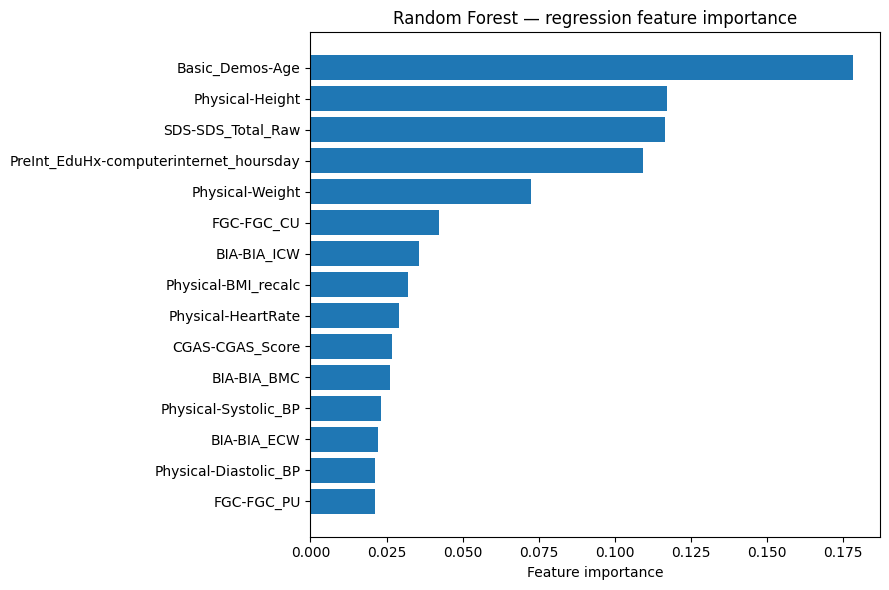

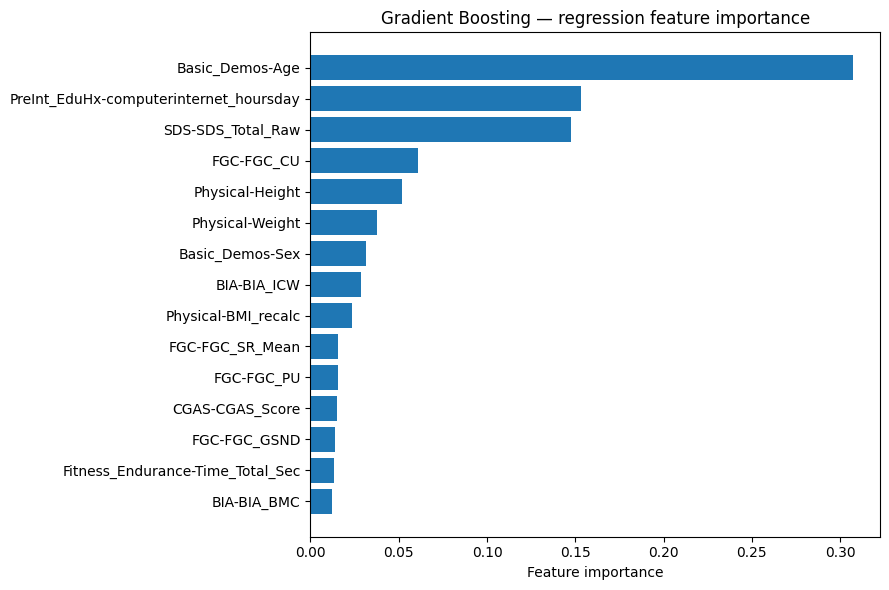

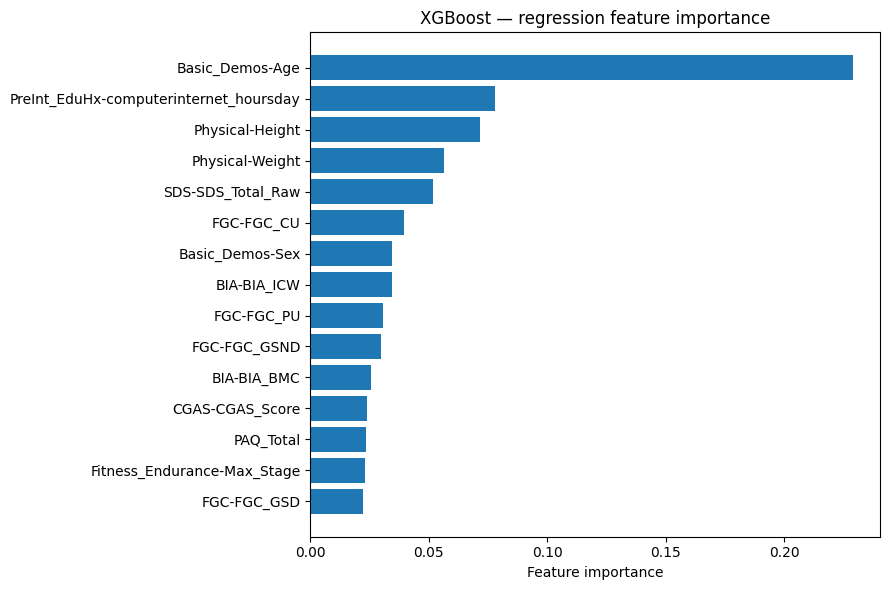

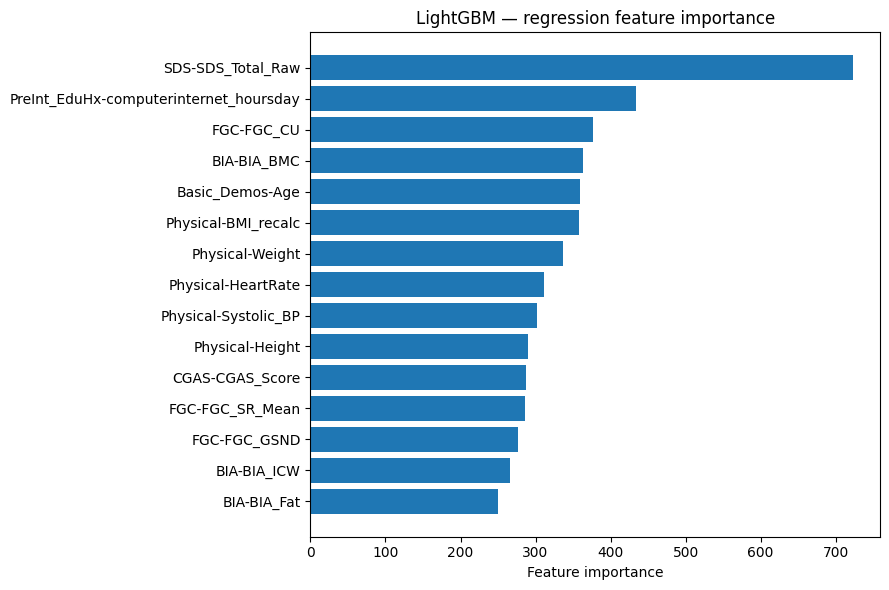

,Random Forest,Gradient Boosting,XGBoost,LightGBM
0,Basic_Demos-Age,Basic_Demos-Age,Basic_Demos-Age,SDS-SDS_Total_Raw
1,Physical-Height,PreInt_EduHx-computerinternet_hoursday,PreInt_EduHx-computerinternet_hoursday,PreInt_EduHx-computerinternet_hoursday
2,SDS-SDS_Total_Raw,SDS-SDS_Total_Raw,Physical-Height,FGC-FGC_CU
3,PreInt_EduHx-computerinternet_hoursday,FGC-FGC_CU,Physical-Weight,BIA-BIA_BMC
4,Physical-Weight,Physical-Height,SDS-SDS_Total_Raw,Basic_Demos-Age


In [10]:
regression_top5 = {}

for model_name, model in regression_models.items():
    importance = model.feature_importances_
    order = np.argsort(importance)[::-1]
    regression_top5[model_name] = [
        reg_feature_cols[i]
        for i in order[:5]
    ]

    plot_idx = order[:15][::-1]
    fig, ax = plt.subplots(figsize=(9, 6))
    ax.barh(
        [reg_feature_cols[i] for i in plot_idx],
        importance[plot_idx],
    )
    ax.set_xlabel("Feature importance")
    ax.set_title(f"{model_name} — regression feature importance")
    plt.tight_layout()
    plt.show()

display(
    pd.DataFrame(
        {
            model: features
            for model, features in regression_top5.items()
        }
    )
)

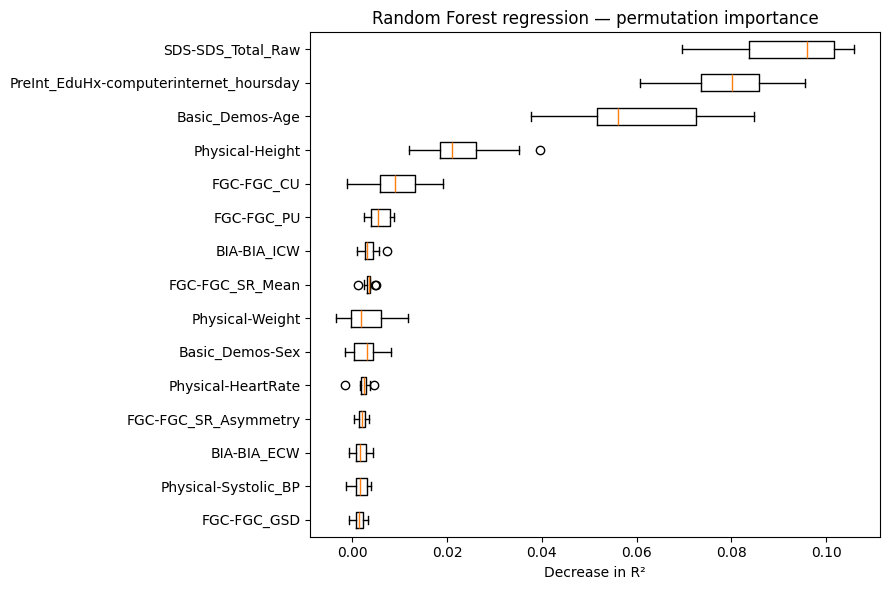

In [11]:
rf_reg = regression_models["Random Forest"]

perm_rf_reg = permutation_importance(
    rf_reg,
    X_reg_test,
    y_reg_test,
    n_repeats=10,
    random_state=RANDOM_STATE,
    n_jobs=1,
)

perm_order = np.argsort(perm_rf_reg.importances_mean)[-15:]

fig, ax = plt.subplots(figsize=(9, 6))
ax.boxplot(
    perm_rf_reg.importances[perm_order].T,
    vert=False,
    tick_labels=np.array(reg_feature_cols)[perm_order],
)
ax.set_xlabel("Decrease in R²")
ax.set_title("Random Forest regression — permutation importance")
plt.tight_layout()
plt.show()

## 14. Predicted vs actual and residual analysis

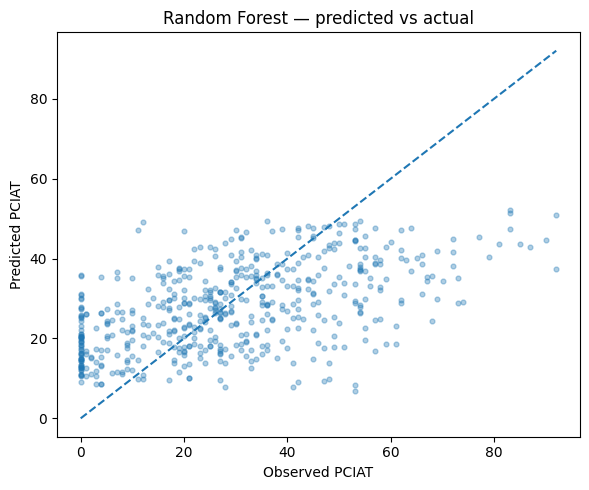

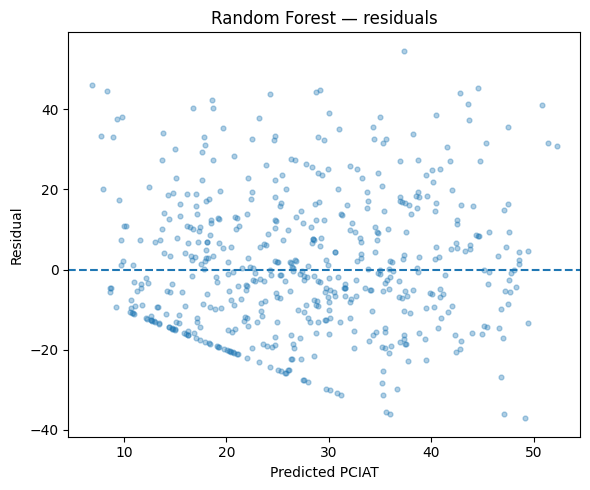

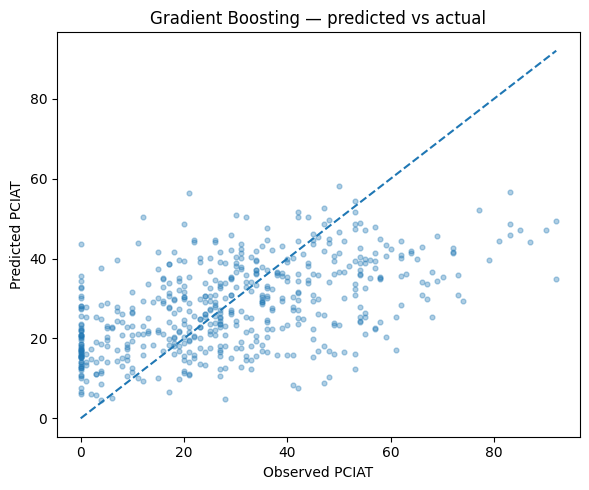

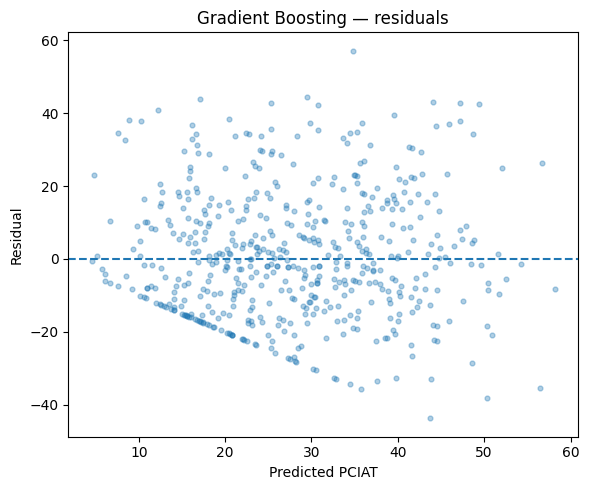

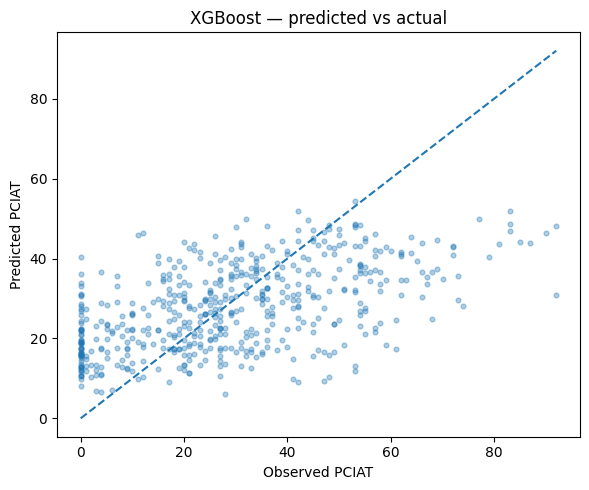

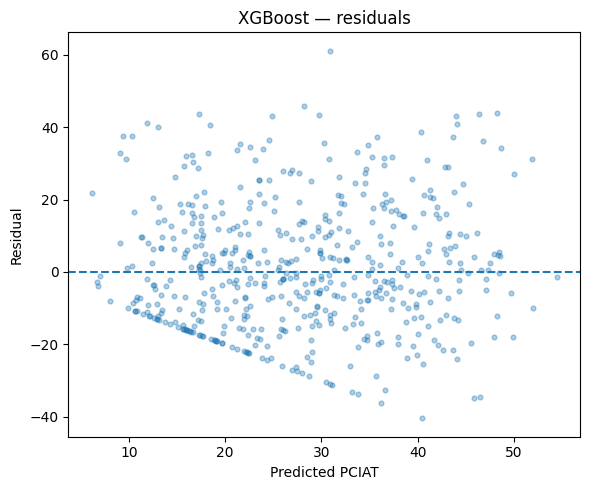

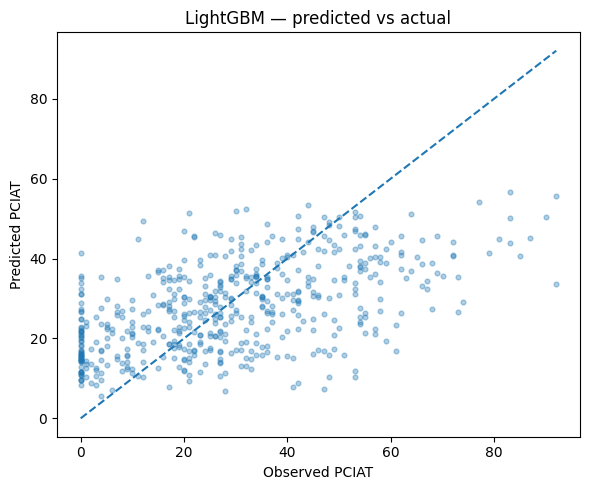

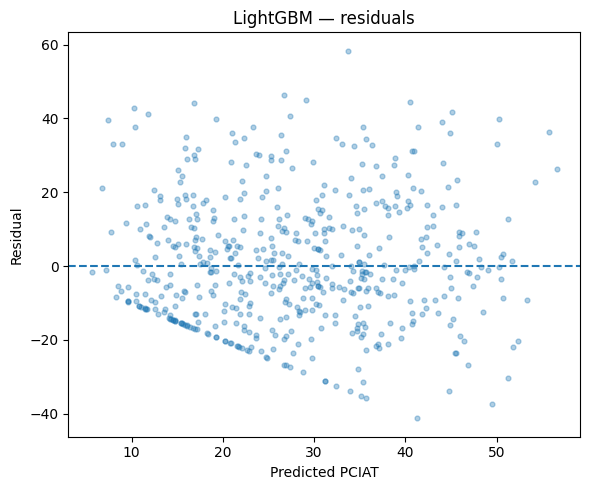

In [12]:
for model_name, pred in regression_predictions.items():
    fig, ax = plt.subplots(figsize=(6, 5))
    ax.scatter(y_reg_test, pred, s=12, alpha=0.35)
    lims = [
        min(y_reg_test.min(), pred.min()),
        max(y_reg_test.max(), pred.max()),
    ]
    ax.plot(lims, lims, linestyle="--")
    ax.set_xlabel("Observed PCIAT")
    ax.set_ylabel("Predicted PCIAT")
    ax.set_title(f"{model_name} — predicted vs actual")
    plt.tight_layout()
    plt.show()

    residuals = y_reg_test - pred
    fig, ax = plt.subplots(figsize=(6, 5))
    ax.scatter(pred, residuals, s=12, alpha=0.35)
    ax.axhline(0, linestyle="--")
    ax.set_xlabel("Predicted PCIAT")
    ax.set_ylabel("Residual")
    ax.set_title(f"{model_name} — residuals")
    plt.tight_layout()
    plt.show()

## 15. Sensitivity analysis — remove direct internet-use exposure

`PreInt_EduHx-computerinternet_hoursday` is not mathematical leakage, but it measures internet/computer exposure directly.

We included a robustness check in which this predictor is removed while keeping the **same train/test indices**.

In [13]:
RUN_REGRESSION_SENSITIVITY = True

if RUN_REGRESSION_SENSITIVITY and PREINT_COL in reg_feature_cols:
    reg_features_no_preint = [
        col for col in reg_feature_cols
        if col != PREINT_COL
    ]

    X_train_no_preint = df_reg.loc[reg_train_idx, reg_features_no_preint].to_numpy()
    X_test_no_preint = df_reg.loc[reg_test_idx, reg_features_no_preint].to_numpy()

    sensitivity_rows = []

    for model_name, spec in reg_model_specs.items():
        search = RandomizedSearchCV(
            spec["class"](**spec["fixed_params"]),
            param_distributions=spec["param_dist"],
            n_iter=30,
            cv=5,
            scoring="neg_mean_absolute_error",
            random_state=RANDOM_STATE,
            n_jobs=1,
            refit=True,
        )
        search.fit(X_train_no_preint, y_reg_train)

        metrics, _ = regression_metrics(
            search.best_estimator_,
            X_test_no_preint,
            y_reg_test,
        )

        sensitivity_rows.append({
            "model": model_name,
            "MAE_without_PreInt": metrics["MAE"],
            "RMSE_without_PreInt": metrics["RMSE"],
            "R2_without_PreInt": metrics["R2"],
        })

    sensitivity_df = pd.DataFrame(sensitivity_rows)

    tuned_with = (
        regression_results
        .loc[regression_results["version"] == "Tuned"]
        .rename(columns={
            "MAE": "MAE_with_PreInt",
            "RMSE": "RMSE_with_PreInt",
            "R2": "R2_with_PreInt",
        })
    )

    sensitivity_comparison = tuned_with.merge(
        sensitivity_df,
        on="model",
        how="left",
    )

    sensitivity_comparison["delta_MAE_without_minus_with"] = (
        sensitivity_comparison["MAE_without_PreInt"]
        - sensitivity_comparison["MAE_with_PreInt"]
    )
    sensitivity_comparison["delta_R2_without_minus_with"] = (
        sensitivity_comparison["R2_without_PreInt"]
        - sensitivity_comparison["R2_with_PreInt"]
    )

    display(sensitivity_comparison.round(4))

,model,version,MAE_with_PreInt,RMSE_with_PreInt,R2_with_PreInt,MAE_without_PreInt,RMSE_without_PreInt,R2_without_PreInt,delta_MAE_without_minus_with,delta_R2_without_minus_with
0,Random Forest,Tuned,13.7865,17.2780,0.2903,14.3385,17.8592,0.2418,0.5520,-0.0486
1,Gradient Boosting,Tuned,13.8213,17.3177,0.2871,14.1759,17.6940,0.2557,0.3547,-0.0313
2,XGBoost,Tuned,13.7733,17.2276,0.2944,14.1814,17.7399,0.2519,0.4081,-0.0426
3,LightGBM,Tuned,13.6736,17.1549,0.3004,14.1762,17.7081,0.2545,0.5025,-0.0459


In [14]:
REGRESSION_RESULTS_PATH = REGRESSION_DIR / "regression_results.csv"
REGRESSION_PARAMS_PATH = REGRESSION_DIR / "regression_best_params.json"

regression_results.to_csv(REGRESSION_RESULTS_PATH, index=False)

with open(REGRESSION_PARAMS_PATH, "w", encoding="utf-8") as f:
    json.dump(regression_best_params, f, indent=2, default=str)

print("Saved:", REGRESSION_RESULTS_PATH)
print("Saved:", REGRESSION_PARAMS_PATH)

Saved: /Users/sarabiiavasco/Codice/DATA MINING/PROGETTO DM2/artifacts/module2_regression/regression_results.csv
Saved: /Users/sarabiiavasco/Codice/DATA MINING/PROGETTO DM2/artifacts/module2_regression/regression_best_params.json



## 16. Save the sensitivity-analysis output

The original final notebook displayed this comparison but did not keep a dedicated CSV for it.  
The standalone version saves it explicitly when the sensitivity analysis has been executed.


In [15]:

if "sensitivity_comparison" in globals():
    SENSITIVITY_PATH = (
        REGRESSION_DIR
        / "regression_preint_sensitivity.csv"
    )

    sensitivity_comparison.to_csv(
        SENSITIVITY_PATH,
        index=False,
    )

    print("Saved:", SENSITIVITY_PATH)
else:
    print("Sensitivity analysis has not been executed.")


Saved: /Users/sarabiiavasco/Codice/DATA MINING/PROGETTO DM2/artifacts/module2_regression/regression_preint_sensitivity.csv
